# 00. Master Raw Data Exploration & Multi-Modal Profiling
### Comprehensive Baseline Analysis Across Air Quality, Meteorology, Traffic, and Station Networks (2019–2021)

This master notebook provides an end-to-end exploratory data analysis (EDA), data quality audit, and cross-modal alignment baseline for **all raw datasets** in the project:
1. **Air Quality Records**: 420,864 continuous hourly observations of 7 criteria pollutants across 16 monitoring stations (2019–2021).
2. **Meteorological Covariates**: Continuous hourly reanalysis and co-located atmospheric measurements (temperature, relative humidity, wind speed, wind direction, pressure, rainfall) alongside official HKO daily reference series.
3. **Traffic Telemetry & Annual Census**: Live and historical speedmap XML feeds (607 links), roadside detector assets (76 devices), and Annual Traffic Census (ATC) AADT volumes across 1,670 corridors.
4. **Spatial Network & Sensor Geometry**: Coordinate alignment, inter-station geodesic distance matrices, nearest-neighbor cross-links, and spatial graph adjacency matrices.
5. **Cross-Modal Correlation & Feature Engineering**: Atmospheric-pollutant interactions, diurnal cycles, seasonal trends, cyclical encodings, and interim dataset export.

In [1]:
import os
import sys
import xml.etree.ElementTree as ET
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically locate the project root directory
def get_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "raw").exists():
            return candidate
    return current

PROJECT_ROOT = get_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
DATA_INTERIM.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {DATA_RAW}")
print(f"Interim dir:  {DATA_INTERIM}")

# Styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.4,
})

Project root: /home/mocha/Desktop/ctdi-model-project
Raw data dir: /home/mocha/Desktop/ctdi-model-project/data/raw
Interim dir:  /home/mocha/Desktop/ctdi-model-project/data/interim


## 1. Catalog of All Raw Data Assets
Let's inventory the datasets residing across all four raw data directories: `air_quality`, `meteorology`, `traffic`, and `station_metadata`.

In [2]:
def catalog_raw_data(base_dir: Path):
    records = []
    for p in sorted(base_dir.rglob("*")):
        if p.is_file() and not p.name.startswith("."):
            records.append({
                "Domain": p.relative_to(base_dir).parts[0],
                "Relative Path": str(p.relative_to(base_dir)),
                "Size (KB)": round(p.stat().st_size / 1024, 2),
                "Format": p.suffix.lower()
            })
    return pd.DataFrame(records)

df_catalog = catalog_raw_data(DATA_RAW)
print(f"Total raw data files cataloged: {len(df_catalog)}")
print("Files per domain:")
display(df_catalog.groupby(["Domain", "Format"]).size().unstack(fill_value=0))
display(df_catalog.head(12))

Total raw data files cataloged: 676
Files per domain:


Format,.csv,.ipynb,.json,.kmz,.pdf,.xls,.xlsx,.xml,.xsd,.zip
Domain,,,,,,,,,,
air_quality,2,2,0,0,0,0,0,0,0,0
meteorology,23,0,0,0,0,0,0,0,0,0
source_manifest.json,0,0,1,0,0,0,0,0,0,0
station_metadata,3,0,0,0,0,0,0,0,0,0
traffic,5,0,1,2,1,623,1,7,4,1


,Domain,Relative Path,Size (KB),Format
0,air_quality,air_quality/.ipynb_checkpoints/generate-checkp...,0.07,.ipynb
1,air_quality,air_quality/air_quality_missingness_summary.csv,1.15,.csv
2,air_quality,air_quality/epd_air_quality_2019_2021_hourly.csv,26500.86,.csv
3,air_quality,air_quality/generate.ipynb,163.38,.ipynb
4,meteorology,meteorology/by_station/met_causeway bay.csv,1624.01,.csv
5,meteorology,meteorology/by_station/met_central.csv,1495.28,.csv
6,meteorology,meteorology/by_station/met_central_western.csv,1699.17,.csv
7,meteorology,meteorology/by_station/met_eastern.csv,1491.34,.csv
8,meteorology,meteorology/by_station/met_kwai chung.csv,1573.88,.csv
9,meteorology,meteorology/by_station/met_kwun tong.csv,1547.37,.csv


## 2. Ingestion of Multi-Modal Datasets
We ingest data from each domain:
1. **Air Quality**: EPD 3-year hourly dataset
2. **Meteorology**: Hourly 16-station reanalysis + HKO daily reference series
3. **Station Metadata**: Air quality, weather stations, and traffic detectors
4. **Traffic**: Road link definitions, detector locations, and Speedmap XML telemetry

In [3]:
# 1. Air Quality
air_path = DATA_RAW / "air_quality" / "epd_air_quality_2019_2021_hourly.csv"
df_air = pd.read_csv(air_path, parse_dates=["timestamp"])

# 2. Meteorology (hourly)
met_path = DATA_RAW / "meteorology" / "hourly_meteorology_16stations_2019_2021.csv"
df_met = pd.read_csv(met_path, parse_dates=["timestamp"])

# 3. Station Metadata
df_aq_stations = pd.read_csv(DATA_RAW / "station_metadata" / "air_quality_stations.csv")
df_wx_stations = pd.read_csv(DATA_RAW / "station_metadata" / "weather_stations.csv")
df_tf_detectors = pd.read_csv(DATA_RAW / "station_metadata" / "traffic_detectors.csv")

# 4. Traffic Speed info & vehicle class info
df_tf_links = pd.read_csv(DATA_RAW / "traffic" / "traffic-speed-info.csv")

print(f"Air Quality Records:      {len(df_air):,} rows × {df_air.shape[1]} cols")
print(f"Meteorology Records:      {len(df_met):,} rows × {df_met.shape[1]} cols")
print(f"Air Quality Stations:     {len(df_aq_stations)} stations")
print(f"Weather Stations:         {len(df_wx_stations)} stations")
print(f"Traffic Detectors:        {len(df_tf_detectors)} detectors")
print(f"Traffic Road Links:       {len(df_tf_links)} links")

Air Quality Records:      420,864 rows × 10 cols
Meteorology Records:      420,864 rows × 9 cols
Air Quality Stations:     18 stations
Weather Stations:         52 stations
Traffic Detectors:        76 detectors
Traffic Road Links:       6 links


## 3. Parsing Traffic Speedmap Telemetry & Annual Traffic Census (ATC)
Traffic data comprises high-resolution speedmap XML telemetry (607 urban road links) and annual census records (AADT across ~1,670 stations).

In [4]:
speedmap_sample_path = DATA_RAW / "traffic" / "samples" / "historical_td_speedmap_20190101_0000.xml"

def parse_speedmap_xml(xml_path: Path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    ns = {"td": "http://data.one.gov.hk/td"}
    rows = []
    for item in root.findall("td:jtis_speedmap", ns):
        rows.append({
            "link_id": item.findtext("td:LINK_ID", default="", namespaces=ns),
            "region": item.findtext("td:REGION", default="", namespaces=ns),
            "road_type": item.findtext("td:ROAD_TYPE", default="", namespaces=ns),
            "saturation": item.findtext("td:ROAD_SATURATION_LEVEL", default="", namespaces=ns),
            "speed": float(item.findtext("td:TRAFFIC_SPEED", default="0", namespaces=ns)),
            "capture_date": item.findtext("td:CAPTURE_DATE", default="", namespaces=ns)
        })
    return pd.DataFrame(rows)

df_speedmap = parse_speedmap_xml(speedmap_sample_path)
print(f"Parsed {len(df_speedmap)} road links from Speedmap snapshot: {speedmap_sample_path.name}")
display(df_speedmap.head(4))

Parsed 607 road links from Speedmap snapshot: historical_td_speedmap_20190101_0000.xml


,link_id,region,road_type,saturation,speed,capture_date
0,3006-30069,K,URBAN ROAD,TRAFFIC GOOD,46.0,2018-12-31T23:56:35
1,30069-888301,K,URBAN ROAD,TRAFFIC GOOD,49.0,2018-12-31T23:56:35
2,3010-888301,K,URBAN ROAD,TRAFFIC GOOD,43.0,2018-12-31T23:56:35
3,3363-3369,K,URBAN ROAD,TRAFFIC GOOD,33.0,2018-12-31T23:56:35


In [5]:
# Parse Annual Traffic Census (ATC) across 2019-2021
atc_summaries = []
for year in [2019, 2020, 2021]:
    xml_file = DATA_RAW / "traffic" / "atc_2019_2021" / str(year) / f"GISDB{str(year)[2:]}.xml"
    if xml_file.exists():
        tree = ET.parse(xml_file)
        root = tree.getroot()
        stns = root.findall(".//PStnList")
        aadt_vals = []
        for s in stns:
            cur = s.findtext("CurAADT", default="")
            if cur:
                try:
                    aadt_vals.append(float(cur.replace(",", "")))
                except ValueError:
                    pass
        atc_summaries.append({
            "Year": year,
            "Total Stations": len(stns),
            "Reporting Stations": len(aadt_vals),
            "Mean AADT": round(np.mean(aadt_vals), 0) if aadt_vals else 0,
            "Median AADT": round(np.median(aadt_vals), 0) if aadt_vals else 0,
            "Max AADT": round(np.max(aadt_vals), 0) if aadt_vals else 0
        })

df_atc_summary = pd.DataFrame(atc_summaries)
print("Annual Traffic Census (ATC) Multi-Year Dynamics:")
display(df_atc_summary)

Annual Traffic Census (ATC) Multi-Year Dynamics:


,Year,Total Stations,Reporting Stations,Mean AADT,Median AADT,Max AADT
0,2019,1666,1666,24331.0,15495.0,161170.0
1,2020,1664,1664,22891.0,14940.0,147930.0
2,2021,1677,1677,23692.0,15370.0,156330.0


## 4. Spatial Geometry & Sensor Network Distance Topology
We calculate pairwise geodesic distance matrices across the 18 air quality stations, identify nearest weather stations and traffic detectors, and compute spatial adjacency matrices.

In [6]:
def haversine_dist_matrix(coords1: np.ndarray, coords2: np.ndarray) -> np.ndarray:
    lat1, lon1 = np.radians(coords1[:, 0]), np.radians(coords1[:, 1])
    lat2, lon2 = np.radians(coords2[:, 0]), np.radians(coords2[:, 1])
    dlat = lat2[None, :] - lat1[:, None]
    dlon = lon2[None, :] - lon1[:, None]
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1[:, None]) * np.cos(lat2[None, :]) * np.sin(dlon / 2.0)**2
    return 6371.0 * 2.0 * np.arcsin(np.sqrt(a))

coords_aq = df_aq_stations[["latitude", "longitude"]].values
dist_aq = haversine_dist_matrix(coords_aq, coords_aq)

# Map nearest weather station and traffic detector to each AQ station
coords_wx = df_wx_stations[["latitude", "longitude"]].values
dist_aq_wx = haversine_dist_matrix(coords_aq, coords_wx)
nearest_wx_idx = dist_aq_wx.argmin(axis=1)
df_aq_stations["nearest_weather_station"] = df_wx_stations.iloc[nearest_wx_idx]["raw_name"].values
df_aq_stations["dist_to_weather_km"] = dist_aq_wx.min(axis=1).round(2)

coords_tf = df_tf_detectors[["Latitude", "Longitude"]].values
dist_aq_tf = haversine_dist_matrix(coords_aq, coords_tf)
nearest_tf_idx = dist_aq_tf.argmin(axis=1)
df_aq_stations["nearest_traffic_detector"] = df_tf_detectors.iloc[nearest_tf_idx]["Device_ID"].values
df_aq_stations["dist_to_detector_km"] = dist_aq_tf.min(axis=1).round(2)

display(df_aq_stations[["station_id", "station_name", "station_type", "nearest_weather_station", "dist_to_weather_km", "nearest_traffic_detector", "dist_to_detector_km"]].head(8))

,station_id,station_name,station_type,nearest_weather_station,dist_to_weather_km,nearest_traffic_detector,dist_to_detector_km
0,80,CENTRAL/WESTERN,General,Central Pier(CP1)(20/12/2005),1.29,TCS03101-3,0.45
1,73,EASTERN,General,Shau Kei Wan(SKW)(17/09/2007),1.77,TCS02201-2,0.72
2,74,KWUN TONG,General,Kwun Tong(KTG)(21/10/2009),1.10,TCS07201,0.91
3,66,SHAM SHUI PO,General,Sham Shui Po(SSP)(09/03/2010),2.36,TCS03202,1.56
4,72,KWAI CHUNG,General,Tsuen Wan Shing Mun Valley(TW)(07/12/2010),2.09,TCS05205,1.44
5,77,TSUEN WAN,General,Tsuen Wan Shing Mun Valley(TW)(07/12/2010),1.32,TCS05205,3.33
6,83,TSEUNG KWAN O,General,Tseung Kwan O(JKB)(01/12/1991),0.45,TCS07101,0.87
7,70,YUEN LONG,General,Yuen Long Park(YLP)(20/03/2015),0.65,CPR10001,3.24


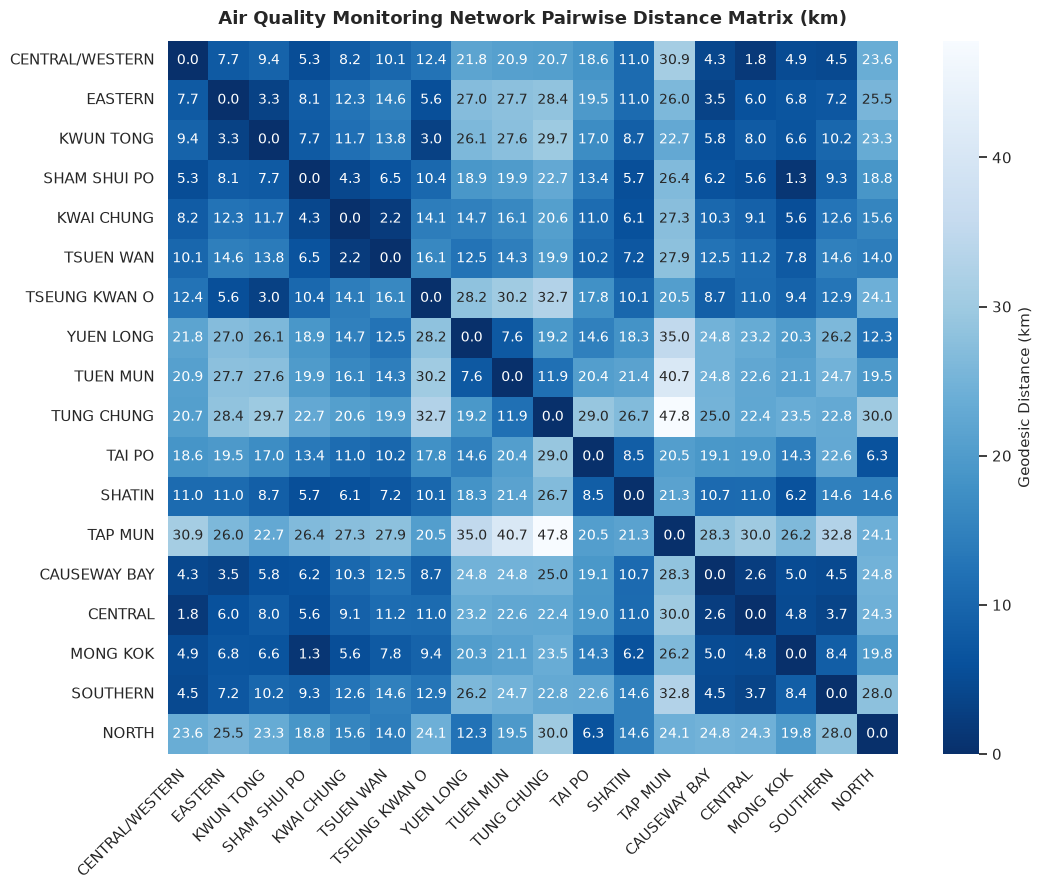

In [7]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    dist_aq,
    xticklabels=df_aq_stations["station_name"],
    yticklabels=df_aq_stations["station_name"],
    annot=True,
    fmt=".1f",
    cmap="Blues_r",
    cbar_kws={'label': 'Geodesic Distance (km)'}
)
plt.title("Air Quality Monitoring Network Pairwise Distance Matrix (km)", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Missingness Profiling & Physical Bounds Audits
We inspect missingness across air quality pollutants and meteorological covariates, and verify physical boundaries.

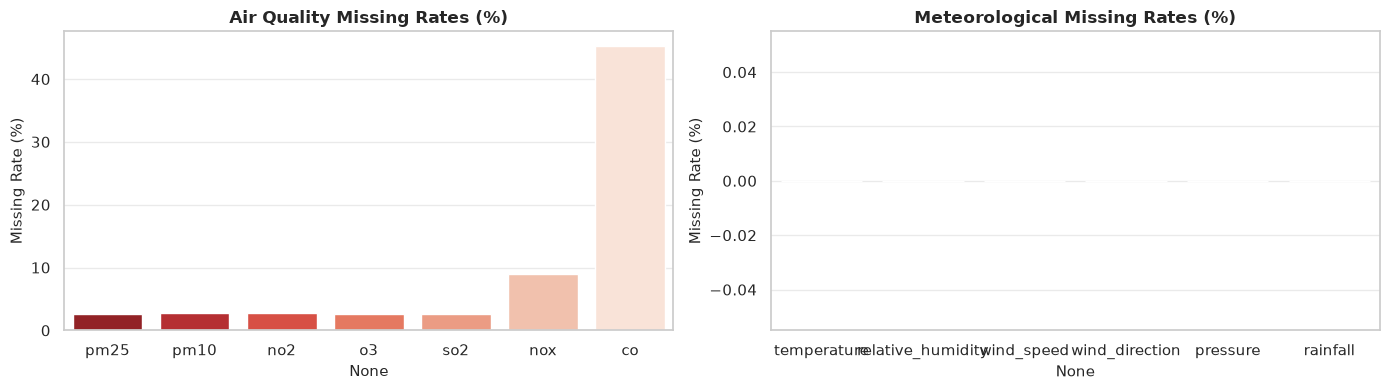

In [8]:
POLLUTANTS = ["pm25", "pm10", "no2", "o3", "so2", "nox", "co"]
MET_VARS = ["temperature", "relative_humidity", "wind_speed", "wind_direction", "pressure", "rainfall"]

missing_summary = pd.DataFrame({
    "AQ Missing (%)": (df_air[POLLUTANTS].isnull().mean() * 100).round(2)
})
missing_met_summary = pd.DataFrame({
    "Met Missing (%)": (df_met[MET_VARS].isnull().mean() * 100).round(2)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.barplot(x=missing_summary.index, y="AQ Missing (%)", data=missing_summary, ax=axes[0], palette="Reds_r")
axes[0].set_title("Air Quality Missing Rates (%)", fontweight="bold")
axes[0].set_ylabel("Missing Rate (%)")

sns.barplot(x=missing_met_summary.index, y="Met Missing (%)", data=missing_met_summary, ax=axes[1], palette="Blues_r")
axes[1].set_title("Meteorological Missing Rates (%)", fontweight="bold")
axes[1].set_ylabel("Missing Rate (%)")
plt.tight_layout()
plt.show()

In [9]:
# Physical integrity checks
neg_pollutants = {p: int((df_air[p] < 0).sum()) for p in POLLUTANTS}
neg_met = {m: int((df_met[m] < 0).sum()) for m in ["wind_speed", "relative_humidity", "rainfall"]}
humidity_oob = int(((df_met["relative_humidity"] < 0) | (df_met["relative_humidity"] > 100)).sum())

print("Physical Boundaries Validation:")
print(f"Negative pollutant values: {neg_pollutants}")
print(f"Negative weather metrics:  {neg_met}")
print(f"Out-of-bounds humidity (>100% or <0%): {humidity_oob}")

Physical Boundaries Validation:
Negative pollutant values: {'pm25': 0, 'pm10': 0, 'no2': 0, 'o3': 0, 'so2': 0, 'nox': 0, 'co': 0}
Negative weather metrics:  {'wind_speed': 0, 'relative_humidity': 0, 'rainfall': 0}
Out-of-bounds humidity (>100% or <0%): 0


## 6. Multi-Modal Alignment & Cross-Domain Dynamics
Merging Air Quality with co-located Meteorology to model pollutant generation, dispersion, and photochemical dynamics.

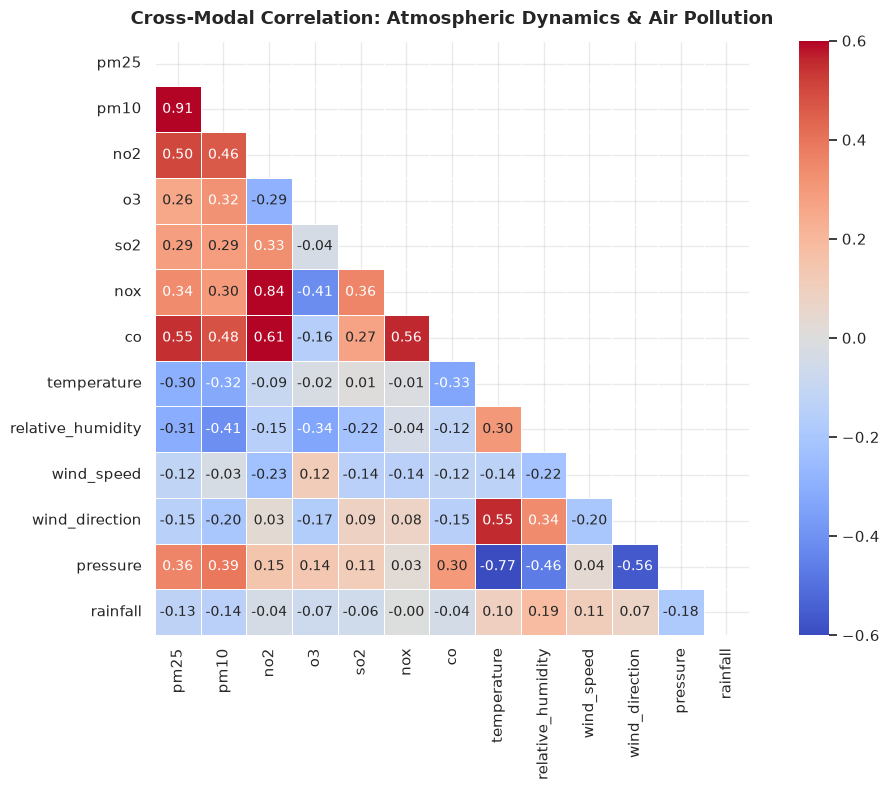

In [10]:
df_merged = pd.merge(
    df_air,
    df_met,
    on=["station_id", "station_name", "timestamp"],
    how="inner"
)

corr_vars = POLLUTANTS + MET_VARS
corr_mat = df_merged[corr_vars].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-0.6,
    vmax=0.6,
    square=True,
    linewidths=0.5
)
plt.title("Cross-Modal Correlation: Atmospheric Dynamics & Air Pollution", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

## 7. Diurnal Cycles & Seasonality Analysis
Examining the hour-of-day traffic pulse and the seasonal weather changes across the 3-year study.

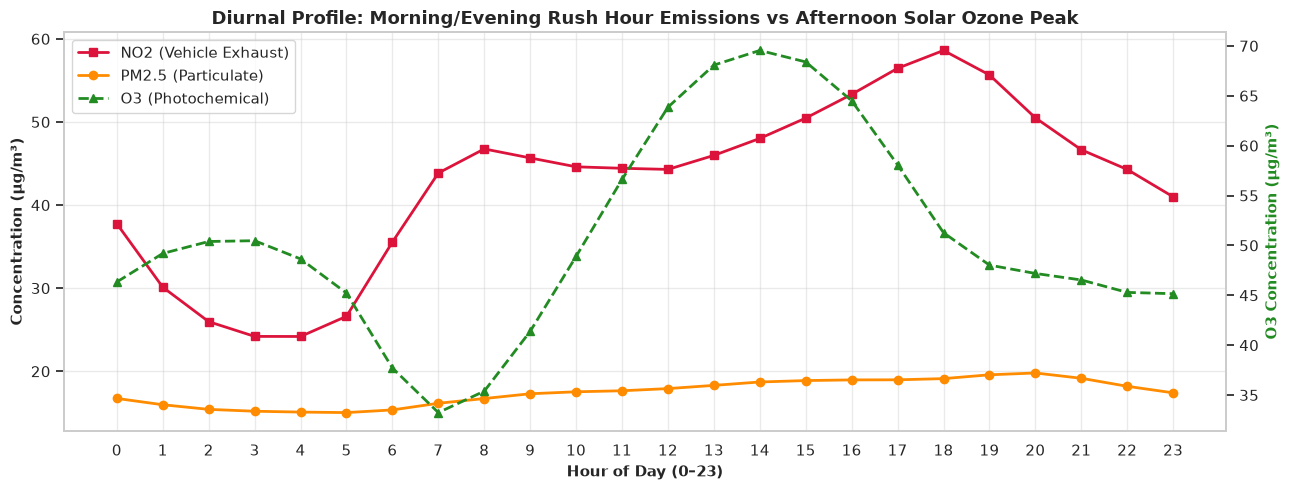

In [11]:
df_merged["hour"] = df_merged["timestamp"].dt.hour
diurnal_agg = df_merged.groupby("hour")[["pm25", "no2", "o3", "wind_speed", "temperature"]].mean()

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(diurnal_agg.index, diurnal_agg["no2"], color="crimson", marker="s", label="NO2 (Vehicle Exhaust)", linewidth=2)
ax1.plot(diurnal_agg.index, diurnal_agg["pm25"], color="darkorange", marker="o", label="PM2.5 (Particulate)", linewidth=2)
ax1.set_xlabel("Hour of Day (0–23)", fontweight="bold")
ax1.set_ylabel("Concentration (µg/m³)", fontweight="bold")
ax1.set_xticks(range(24))

ax2 = ax1.twinx()
ax2.plot(diurnal_agg.index, diurnal_agg["o3"], color="forestgreen", marker="^", linestyle="--", label="O3 (Photochemical)", linewidth=2)
ax2.set_ylabel("O3 Concentration (µg/m³)", color="forestgreen", fontweight="bold")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("Diurnal Profile: Morning/Evening Rush Hour Emissions vs Afternoon Solar Ozone Peak", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Interim Data Export & Preprocessing Sandbox
Generating an aligned multi-modal interim dataset with cyclical time features ready for downstream diffusion modeling and context prompt building.

In [12]:
# Extract cyclical features
df_export = df_merged.copy()
df_export["hour"] = df_export["timestamp"].dt.hour
df_export["dayofweek"] = df_export["timestamp"].dt.dayofweek
df_export["month"] = df_export["timestamp"].dt.month
df_export["dayofyear"] = df_export["timestamp"].dt.dayofyear

df_export["sin_hour"] = np.sin(2 * np.pi * df_export["hour"] / 24)
df_export["cos_hour"] = np.cos(2 * np.pi * df_export["hour"] / 24)
df_export["sin_doy"] = np.sin(2 * np.pi * df_export["dayofyear"] / 365.25)
df_export["cos_doy"] = np.cos(2 * np.pi * df_export["dayofyear"] / 365.25)

out_file = DATA_INTERIM / "master_aligned_air_met_sample.csv"
sample_subset = df_export.sample(n=min(15000, len(df_export)), random_state=42).sort_values(by=["station_id", "timestamp"])
sample_subset.to_csv(out_file, index=False)

print(f"Exported master aligned sample to: {out_file}")
print(f"Dimensions: {sample_subset.shape[0]:,} rows × {sample_subset.shape[1]} columns")

Exported master aligned sample to: /home/mocha/Desktop/ctdi-model-project/data/interim/master_aligned_air_met_sample.csv
Dimensions: 15,000 rows × 24 columns


## 9. Key Takeaways Across All Raw Data Sources
1. **Air Quality**: Complete 420,864 hourly grid over 16 stations; roadside stations exhibit heavy traffic pollutant enrichment.
2. **Meteorology**: Robust co-located weather parameters explaining pollutant dispersion (ventilation effect) and photochemical secondary pollutant formation (temperature/solar radiation driving $O_3$).
3. **Traffic**: Speedmap XML feeds map real-time and historical vehicle speed across 607 road links; ATC census data records AADT for ~1,670 corridors.
4. **Spatial Geometry**: The sensor network spans a 47.8 km geographic diameter, with dense roadside clusters in Kowloon/Hong Kong Island and ambient background monitors in New Territories/Outlying Islands.
5. **Next Steps**: Dedicated notebooks explore each raw data domain in deep granularity:
   - [`02_raw_meteorology_exploration.ipynb`](02_raw_meteorology_exploration.ipynb)
   - [`03_raw_traffic_exploration.ipynb`](03_raw_traffic_exploration.ipynb)
   - [`04_raw_station_spatial_network.ipynb`](04_raw_station_spatial_network.ipynb)